In [13]:
import pandas as pd
import numpy as np
import datetime as dt
import glob

from XMA_finder import XMA_finder
from Cluster_CDF_conv import Cluster_cdf_conv
#from histo_plot_lower_vmax import histo_plot
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

#import modules
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import cm
import matplotlib.colors as colors
from merka05_surface_eq_array_GIPM import merka05_surface_eq_array_GIPM
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import TransformedBbox

In [2]:
#import Cluster integrated CSVs, separated by spacecraft in order to match w/Fourier spectra
#import C1/C2/C3/C4 csvs and determine min/max power
#then go back to update the colourmap norm choice

##load Cluster CSVs

c1_file_list = []
c2_file_list = []
c3_file_list = []
c4_file_list = []

path = "/Users/roseatkinson/Documents/Cluster_Integrated_CSVs/Integrated_CSVs_2001/**"

for path in glob.glob(path, recursive=True):
    if '.csv' in path:
        if 'C1' in path:
            c1_file_list.append(path)
        if 'C2' in path:
            c2_file_list.append(path)   
        if 'C3' in path:
            c3_file_list.append(path)
        if 'C4' in path:
            c4_file_list.append(path)

cl_csvs = [c1_file_list, c2_file_list, c3_file_list, c4_file_list]
            
c1_dfs = []
c2_dfs = []
c3_dfs = []
c4_dfs = []

cl_dfs = [c1_dfs, c2_dfs, c3_dfs, c4_dfs]

for csv_list, df_list in zip(cl_csvs, cl_dfs):
    for file in csv_list:
        df = pd.read_csv(file,encoding='utf-8')
        df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
        df.set_index('datetime', inplace = True)
        df_list.append(df)

cl_1_df = pd.concat(c1_dfs)
cl_2_df = pd.concat(c2_dfs)
cl_3_df = pd.concat(c3_dfs)
cl_4_df = pd.concat(c4_dfs)

#Filtering: remove OMNI too far, current sheets, & null GIPM entries
cl_1_filtered = cl_1_df.loc[(cl_1_df['OMNI Dist from X line (mean)'] < 70) & (cl_1_df['Max IMF Deviation'] < 60) & (cl_1_df['GIPM X (OMNI mean)'].notnull())]
cl_2_filtered = cl_2_df.loc[(cl_2_df['OMNI Dist from X line (mean)'] < 70) & (cl_2_df['Max IMF Deviation'] < 60) & (cl_2_df['GIPM X (OMNI mean)'].notnull())]
cl_3_filtered = cl_3_df.loc[(cl_3_df['OMNI Dist from X line (mean)'] < 70) & (cl_3_df['Max IMF Deviation'] < 60) & (cl_3_df['GIPM X (OMNI mean)'].notnull())]
cl_4_filtered = cl_4_df.loc[(cl_4_df['OMNI Dist from X line (mean)'] < 70) & (cl_4_df['Max IMF Deviation'] < 60) & (cl_4_df['GIPM X (OMNI mean)'].notnull())]

cl_1_filtered_lowZ = cl_1_filtered.loc[(cl_1_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_1_filtered['GIPM Z (OMNI mean)'] > -5)]
cl_2_filtered_lowZ = cl_2_filtered.loc[(cl_2_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_2_filtered['GIPM Z (OMNI mean)'] > -5)]
cl_3_filtered_lowZ = cl_3_filtered.loc[(cl_3_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_3_filtered['GIPM Z (OMNI mean)'] > -5)]
cl_4_filtered_lowZ = cl_4_filtered.loc[(cl_4_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_4_filtered['GIPM Z (OMNI mean)'] > -5)]


In [5]:
#first off: looking at polarisation by taking ratio of power in two transverse components 
#will need to match the spectra to the Cluster GIPM measurement

#/Users/roseatkinson/Documents/Spectra_2001
#example file:
#'/Users/roseatkinson/Documents/Spectra_2001/FS_2001-02-02 19:14:00_C4.csv'
#iterate through filtered cluster datasets
#make new dataframe with the datetimes as the index and the results as columns
#then later join on df index to original df with the rest of the cluster data
cl_1_datetimes = []
cl_1_peak_freqs = []
cl_1_ellipticity = []

cl_2_datetimes = []
cl_2_peak_freqs = []
cl_2_ellipticity = []

cl_3_datetimes = []
cl_3_peak_freqs = []
cl_3_ellipticity = []

cl_4_datetimes = []
cl_4_peak_freqs = []
cl_4_ellipticity = []

#temporarily keeping loaded dfs for testing
spectra_1_dfs = []
spectra_2_dfs = []
spectra_3_dfs = []
spectra_4_dfs = []

df_list = [cl_1_filtered_lowZ, cl_2_filtered_lowZ, cl_3_filtered_lowZ, cl_4_filtered_lowZ]
sc_list = ['C1', 'C2', 'C3', 'C4']
dt_lists = [cl_1_datetimes, cl_2_datetimes, cl_3_datetimes, cl_4_datetimes]
freq_lists = [cl_1_peak_freqs, cl_2_peak_freqs, cl_3_peak_freqs, cl_4_peak_freqs]
ellip_lists = [cl_1_ellipticity, cl_2_ellipticity, cl_3_ellipticity, cl_4_ellipticity]
spec_lists = [spectra_1_dfs, spectra_2_dfs, spectra_3_dfs, spectra_4_dfs]

for df, sc, dt_list, freq_list, ellip_list, spec_list in zip(df_list, sc_list, dt_lists, freq_lists, ellip_lists, spec_lists):

    for datetime in df.index:
        dt_list.append(datetime)
        filename = '/Users/roseatkinson/Documents/Spectra_2001/FS_'+ str(datetime) + '_'+sc+'.csv'
        f_df = pd.read_csv(filename)
        spec_list.append(f_df)
        #find the index of peak compressive power
        max_pwr_idx = f_df[['Parallel Power']].idxmax()
        max_freq = f_df.loc[max_pwr_idx, 'Freq'].values[0]
        freq_list.append(max_freq)
        
        ## Compute the power into the required frequency range using midpoint integration
        F_LOW,F_HIGH = 7e-3,1e-1
        #make np arrays of columns first
        freq = f_df['Freq'].to_numpy()
        p_perp_1 = f_df['Perp 1 Power'].to_numpy()
        p_perp_2 = f_df['Perp 2 Power'].to_numpy()
        mask = (freq>F_LOW) & (freq<F_HIGH)
        delta_f = freq[1] - freq[0]
        P_perp_1 = np.sum(p_perp_1[mask])*delta_f
        P_perp_2 = np.sum(p_perp_2[mask])*delta_f
    
        if P_perp_1 > P_perp_2:
            ratio = P_perp_1/P_perp_2
            ellip_list.append(ratio)
        else:
            ratio = P_perp_2/P_perp_1
            ellip_list.append(ratio)
        
#make new dfs

new_cl_1_df = pd.DataFrame({
    'time': cl_1_datetimes,
    'Peak Frequency': cl_1_peak_freqs,
    'Perp 1/Perp 2': cl_1_ellipticity
})

new_cl_1_df.set_index('time', inplace=True)

new_cl_2_df = pd.DataFrame({
    'time': cl_2_datetimes,
    'Peak Frequency': cl_2_peak_freqs,
    'Perp 1/Perp 2': cl_2_ellipticity
})

new_cl_2_df.set_index('time', inplace=True)

new_cl_3_df = pd.DataFrame({
    'time': cl_3_datetimes,
    'Peak Frequency': cl_3_peak_freqs,
    'Perp 1/Perp 2': cl_3_ellipticity
})

new_cl_3_df.set_index('time', inplace=True)

new_cl_4_df = pd.DataFrame({
    'time': cl_4_datetimes,
    'Peak Frequency': cl_4_peak_freqs,
    'Perp 1/Perp 2': cl_4_ellipticity
})

new_cl_4_df.set_index('time', inplace=True)

c1_full = cl_1_filtered_lowZ.join(new_cl_1_df)
c2_full = cl_2_filtered_lowZ.join(new_cl_2_df)
c3_full = cl_3_filtered_lowZ.join(new_cl_3_df)
c4_full = cl_4_filtered_lowZ.join(new_cl_4_df)


In [7]:
spec_0 = spectra_1_dfs[2]
    
idx_max = spec_0[['Parallel Power']].idxmax()

spec_0.loc[idx_max,'Freq'].values[0]

np.float64(0.0124860646599777)

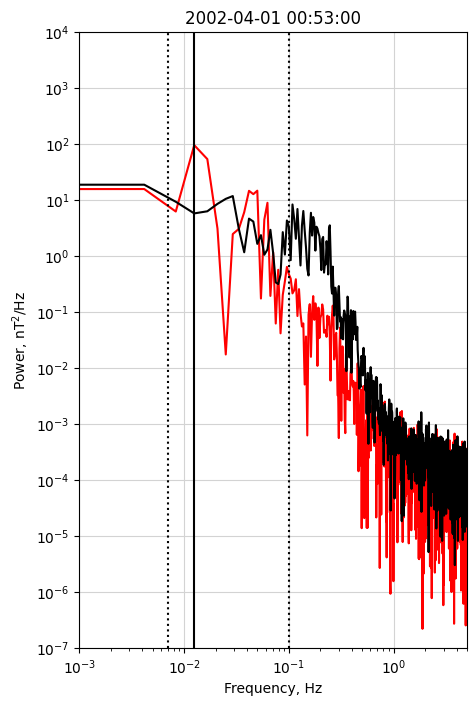

In [8]:
frequency = spec_0['Freq']
perp_power = spec_0['Perp 1 Power'] + spec_0['Perp 2 Power']
para_power = spec_0['Parallel Power']

idx_max_freq = spec_0[['Parallel Power']].idxmax()
max_freq = spec_0.loc[idx_max_freq,'Freq'].values[0]

int_lower_lim = 7*(10**(-3))
int_upper_lim = 100*(10**(-3))

fig, ax = plt.subplots(figsize = (5, 8))

ax.set_title('2002-04-01 00:53:00')
ax.plot(frequency, para_power, color="red", label='Parallel Power')
ax.plot(frequency, perp_power, color="black", label='Perpendicular Power')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Power, $\mathrm{nT^2/Hz}$')
ax.set_xlabel('Frequency, Hz')
ax.set_xlim(0.001, 5)
ax.set_ylim(0.0000001, 10000)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15))
#ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, numticks=10))
ax.vlines(x=max_freq, ymin = 0.0000001, ymax = 10000, linestyles='-', color='k', label='Lower Bound')
ax.vlines(x=int_lower_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k', label='Lower Bound')
ax.vlines(x=int_upper_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k', label='Upper Bound')
#ax.legend(loc='lower center')
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=16) 

ax.set_axisbelow(True)
ax.yaxis.grid(color='lightgray')
ax.xaxis.grid(color='lightgray')

In [9]:
x_bin_edges = range(20)
y_bin_edges = range(-20, 20)

_, xedg, yedg = np.histogram2d(
        c1_full['GIPM X (OMNI mean)'].to_numpy(),
        c1_full['GIPM Y (OMNI mean)'].to_numpy(),
        bins=[x_bin_edges, y_bin_edges]
    )

XMA_all = 10
#Shue magnetopause model, D = 1.76 nPa

m_1 = 10.22
m_2 = 1.29
m_3 = 0.184
m_4 = 8.14
m_5 = 6.6
m_6 = 0.58
m_7 = -0.007
m_8 = 0.024

#use B_z = 0
B_z = 0
D_p = 1.76

alpha = (m_6 + m_7*B_z)*(1 +m_8*(np.log(D_p)))

tanh_angle = m_3*(B_z+m_4)
r_0 = (m_1 + m_2*np.tanh(tanh_angle))*(D_p**(-1/m_5))

pi = np.pi

theta = np.arange(-pi/2, pi/2, 0.01)

r_mod = (2/(1+np.cos(theta)))**alpha
r = r_0*r_mod

X_shue = r*(np.cos(theta))
R_shue = r*(np.sin(theta))

#make a coverage plot

x = np.linspace(0, 20, 100) #x coordinates (Re)
y = np.linspace(-30, 30, 100) #y coordinates (Re)
z = 0 #z coordinates in Re

[Xgipm,Ygipm,Zgipm] = np.meshgrid(x,y,z,indexing="ij")

fitting_coeffs = merka05_surface_eq_array_GIPM(XMA_all)

Xn = Xgipm
Yn = Ygipm
Zn = Zgipm
f = fitting_coeffs[0]*Xn**2 + fitting_coeffs[1]*Yn**2 + fitting_coeffs[2]*Zn**2+ 2*fitting_coeffs[3]*Xn*Yn + 2*fitting_coeffs[4]*Yn*Zn + 2*fitting_coeffs[5]*Xn*Zn + 2*fitting_coeffs[6]*Xn+2*fitting_coeffs[7]*Yn + 2*fitting_coeffs[8]*Zn + fitting_coeffs[9]


# -------------------------------
# Helper functions
# -------------------------------

def draw_background(ax, xg, yg, f, x_shue, r_shue):
    """Draw magnetopause, bow shock + y=0 line"""
    ax.contour(xg, yg, f, levels=[0], colors="black", linewidths=1)
    ax.plot(x_shue, r_shue, 'k', linewidth=1)
    ax.hlines(0, 0, 25, color='k', linewidth=1)


def draw_hist(ax, hist, extent, cmap, angle_line):
    """Draw heatmap + flow line"""
    ax.imshow(hist, interpolation='none', origin='lower',
              extent=extent, cmap=cmap, vmin=50, vmax=300)
    
    x_s, x_e, y_s, y_e = angle_line
    ax.plot([x_s, x_e], [y_s, angle_line[3]], color='k', linewidth=1)

def set_limits(ax):
    ax.set_xlim(0, 20)
    ax.set_ylim(-20, 20)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_aspect('equal')

# -------------------------------
# PRECOMPUTED CONSTANTS
# -------------------------------

# Bow shock intercept
inter_med = fitting_coeffs[6]**2 - (fitting_coeffs[0]*fitting_coeffs[9])
x_s = (-fitting_coeffs[6] + np.sqrt(inter_med)) / fitting_coeffs[0]
x_e = 30
y_s = 0

# Line slopes for different angle classes
line_slopes = {
    "0–30°": np.tan(np.deg2rad(15)),
    "30–45°": np.tan(np.deg2rad(37.5)),
    "45–60°": np.tan(np.deg2rad(52.5)),
    "60–75°": np.tan(np.deg2rad(67.5)),
    "75–90°": np.tan(np.deg2rad(82.5)),
    "30-52.5°": np.tan(np.deg2rad(41.25)),
    "52.5-75°": np.tan(np.deg2rad(63.75)),
}

angle_titles = ["0–30°", "30–45°", "45–60°", "60–75°", "75–90°"]

# Heatmap extent (assuming X/Y are same for all)
extent = [xedg[0], xedg[-1], yedg[0], yedg[-1]]

def mask_inside_magnetopause(ax, x_shue, r_shue):
    """
    Mask (fill white) the region inside the magnetopause and bounded by x=0.
    
    Parameters
    ----------
    ax : matplotlib axis
        Axis to draw on
    x_shue : array
        X coordinates of magnetopause
    r_shue : array
        R (Y) coordinates of magnetopause
    zorder : int zorder=10
        Draw order (should be higher than background contours)
    """

    # Ensure arrays are numpy arrays
    x_shue = np.asarray(x_shue)
    r_shue = np.asarray(r_shue)

    # Magnetopause runs from theta = -pi/2 to pi/2
    # So first point is lower flank, last point is upper flank
    x_lower, y_lower = x_shue[0], r_shue[0]
    x_upper, y_upper = x_shue[-1], r_shue[-1]

    # Build closed polygon:
    # magnetopause curve
    poly_x = list(x_shue)
    poly_y = list(r_shue)

    # connect upper flank to (0,0)
    poly_x.append(0)
    poly_y.append(0)

    # connect (0,0) back to lower flank
    poly_x.append(0)
    poly_y.append(0)

    # close polygon automatically by fill , zorder=zorder
    ax.fill(poly_x, poly_y, color='white')


In [11]:
cl_new_list = pd.concat([c1_full, c2_full, c3_full, c4_full])

#now produce foreshock maps across larger bins: 30-52.5 and 52.5-75
#coverage histograms

df_30_52 = cl_new_list.loc[(cl_new_list['cone angle (mean)'] > 30) & (cl_new_list['cone angle (mean)'] < 52.5)]
df_52_75 = cl_new_list.loc[(cl_new_list['cone angle (mean)'] > 52.5) & (cl_new_list['cone angle (mean)'] < 75)]

#create compressibility column for each dataframe
df_list = [df_30_52 , df_52_75]
    
#df_30_52 

df_30_52_5_10 = df_30_52.loc[((df_30_52['M_A (mean)'] >= 5) & (df_30_52['M_A (mean)'] < 10))]
df_30_52_10_15 = df_30_52.loc[((df_30_52['M_A (mean)'] >= 10) & (df_30_52['M_A (mean)'] < 15))]

#52_75 

df_52_75_5_10 = df_52_75.loc[((df_52_75['M_A (mean)'] >= 5) & (df_52_75['M_A (mean)'] < 10))]
df_52_75_10_15 = df_52_75.loc[((df_52_75['M_A (mean)'] >= 10) & (df_52_75['M_A (mean)'] < 15))]

#updated to include heatmaps, with bins w/ under 50 obs removed.

def compute_hists2d(df):
    """Compute transposed 2D histogram with zeros replaced by NaN."""
    x_col='GIPM X (OMNI mean)'
    y_col='GIPM Y (OMNI mean)'
    w_freq='Peak Frequency'
    w_ellip='Perp 1/Perp 2'

    hist, _, _ = np.histogram2d(
        df[x_col].to_numpy(),
        df[y_col].to_numpy(),
        bins=[x_bin_edges, y_bin_edges]
    )
    hist = hist.T
    hist[hist == 0] = np.nan

    #produce a copy of count distribution histogram for masking purposes
    hist_count = hist.copy()
    #temporarily removing 50-count requirement
    #hist_count[hist_count < 50] = np.nan

    #peak frequency histogram
    hist_freq, _, _ = np.histogram2d(
        df[x_col].to_numpy(),
        df[y_col].to_numpy(),
        bins=[x_bin_edges, y_bin_edges],
        weights=df[w_freq].to_numpy()
    )
    hist_freq = hist_freq.T
    hist_freq[hist_freq == 0] = np.nan
    #normalise to find averages
    hist_freq = hist_freq/hist_count

    #ellipticity power histogram
    hist_ellip, _, _ = np.histogram2d(
        df[x_col].to_numpy(),
        df[y_col].to_numpy(),
        bins=[x_bin_edges, y_bin_edges],
        weights=df[w_ellip].to_numpy()
    )
    hist_ellip = hist_ellip.T
    hist_ellip[hist_ellip == 0] = np.nan
    #normalise to find averages
    hist_ellip = hist_ellip/hist_count

    return hist, hist_freq, hist_ellip

data_groups_ba_MA = {
    "ca_30_52": {
        "5_10": df_30_52_5_10,
        "10_15": df_30_52_10_15,
    },
    "ca_52_75": {
        "5_10": df_52_75_5_10,
        "10_15": df_52_75_10_15,
    }
}

histograms_ba_MA = {}
frequency_heatmap_ba_MA = {}
ellipticity_heatmap_ba_MA = {}

for group_name, subsets in data_groups_ba_MA.items():
    histograms_ba_MA[group_name] = {}
    frequency_heatmap_ba_MA[group_name] = {}
    ellipticity_heatmap_ba_MA[group_name] = {}
    for subset_name, df in subsets.items():
        histograms_ba_MA[group_name][subset_name], frequency_heatmap_ba_MA[group_name][subset_name], ellipticity_heatmap_ba_MA[group_name][subset_name] = compute_hists2d(df)

#produce new heatmap blocks


frequency_ratio_heatmap_ba_MA = {
    'ca_30_52': frequency_heatmap_ba_MA["ca_30_52"]["10_15"]/frequency_heatmap_ba_MA["ca_30_52"]["5_10"],
    "ca_52_75": frequency_heatmap_ba_MA["ca_52_75"]["10_15"]/frequency_heatmap_ba_MA["ca_52_75"]["5_10"],
}

ellipticity_ratio_heatmap_ba_MA = {
    'ca_30_52': ellipticity_heatmap_ba_MA["ca_30_52"]["10_15"]/ellipticity_heatmap_ba_MA["ca_30_52"]["5_10"],
    "ca_52_75": ellipticity_heatmap_ba_MA["ca_52_75"]["10_15"]/ellipticity_heatmap_ba_MA["ca_52_75"]["5_10"],
}

#now make new blocks just for 10-15 & 5-10, and ratios

freq_blocks = [
    [frequency_heatmap_ba_MA["ca_30_52"]["10_15"], frequency_heatmap_ba_MA["ca_52_75"]["10_15"]],
    [frequency_heatmap_ba_MA["ca_30_52"]["5_10"], frequency_heatmap_ba_MA["ca_52_75"]["5_10"]],
    [frequency_ratio_heatmap_ba_MA['ca_30_52'], frequency_ratio_heatmap_ba_MA["ca_52_75"]]
]

ellipicity_blocks = [
    [ellipticity_heatmap_ba_MA["ca_30_52"]["10_15"], ellipticity_heatmap_ba_MA["ca_52_75"]["10_15"]],
    [ellipticity_heatmap_ba_MA["ca_30_52"]["5_10"], ellipticity_heatmap_ba_MA["ca_52_75"]["5_10"]],
    [ellipticity_ratio_heatmap_ba_MA['ca_30_52'], ellipticity_ratio_heatmap_ba_MA["ca_52_75"]]
]



In [22]:
np.nanmax(frequency_heatmap_ba_MA["ca_30_52"]["10_15"])

np.float64(0.12973967130863778)

In [23]:
np.nanmin(frequency_heatmap_ba_MA["ca_30_52"]["10_15"])

np.float64(0.00046250412950113337)

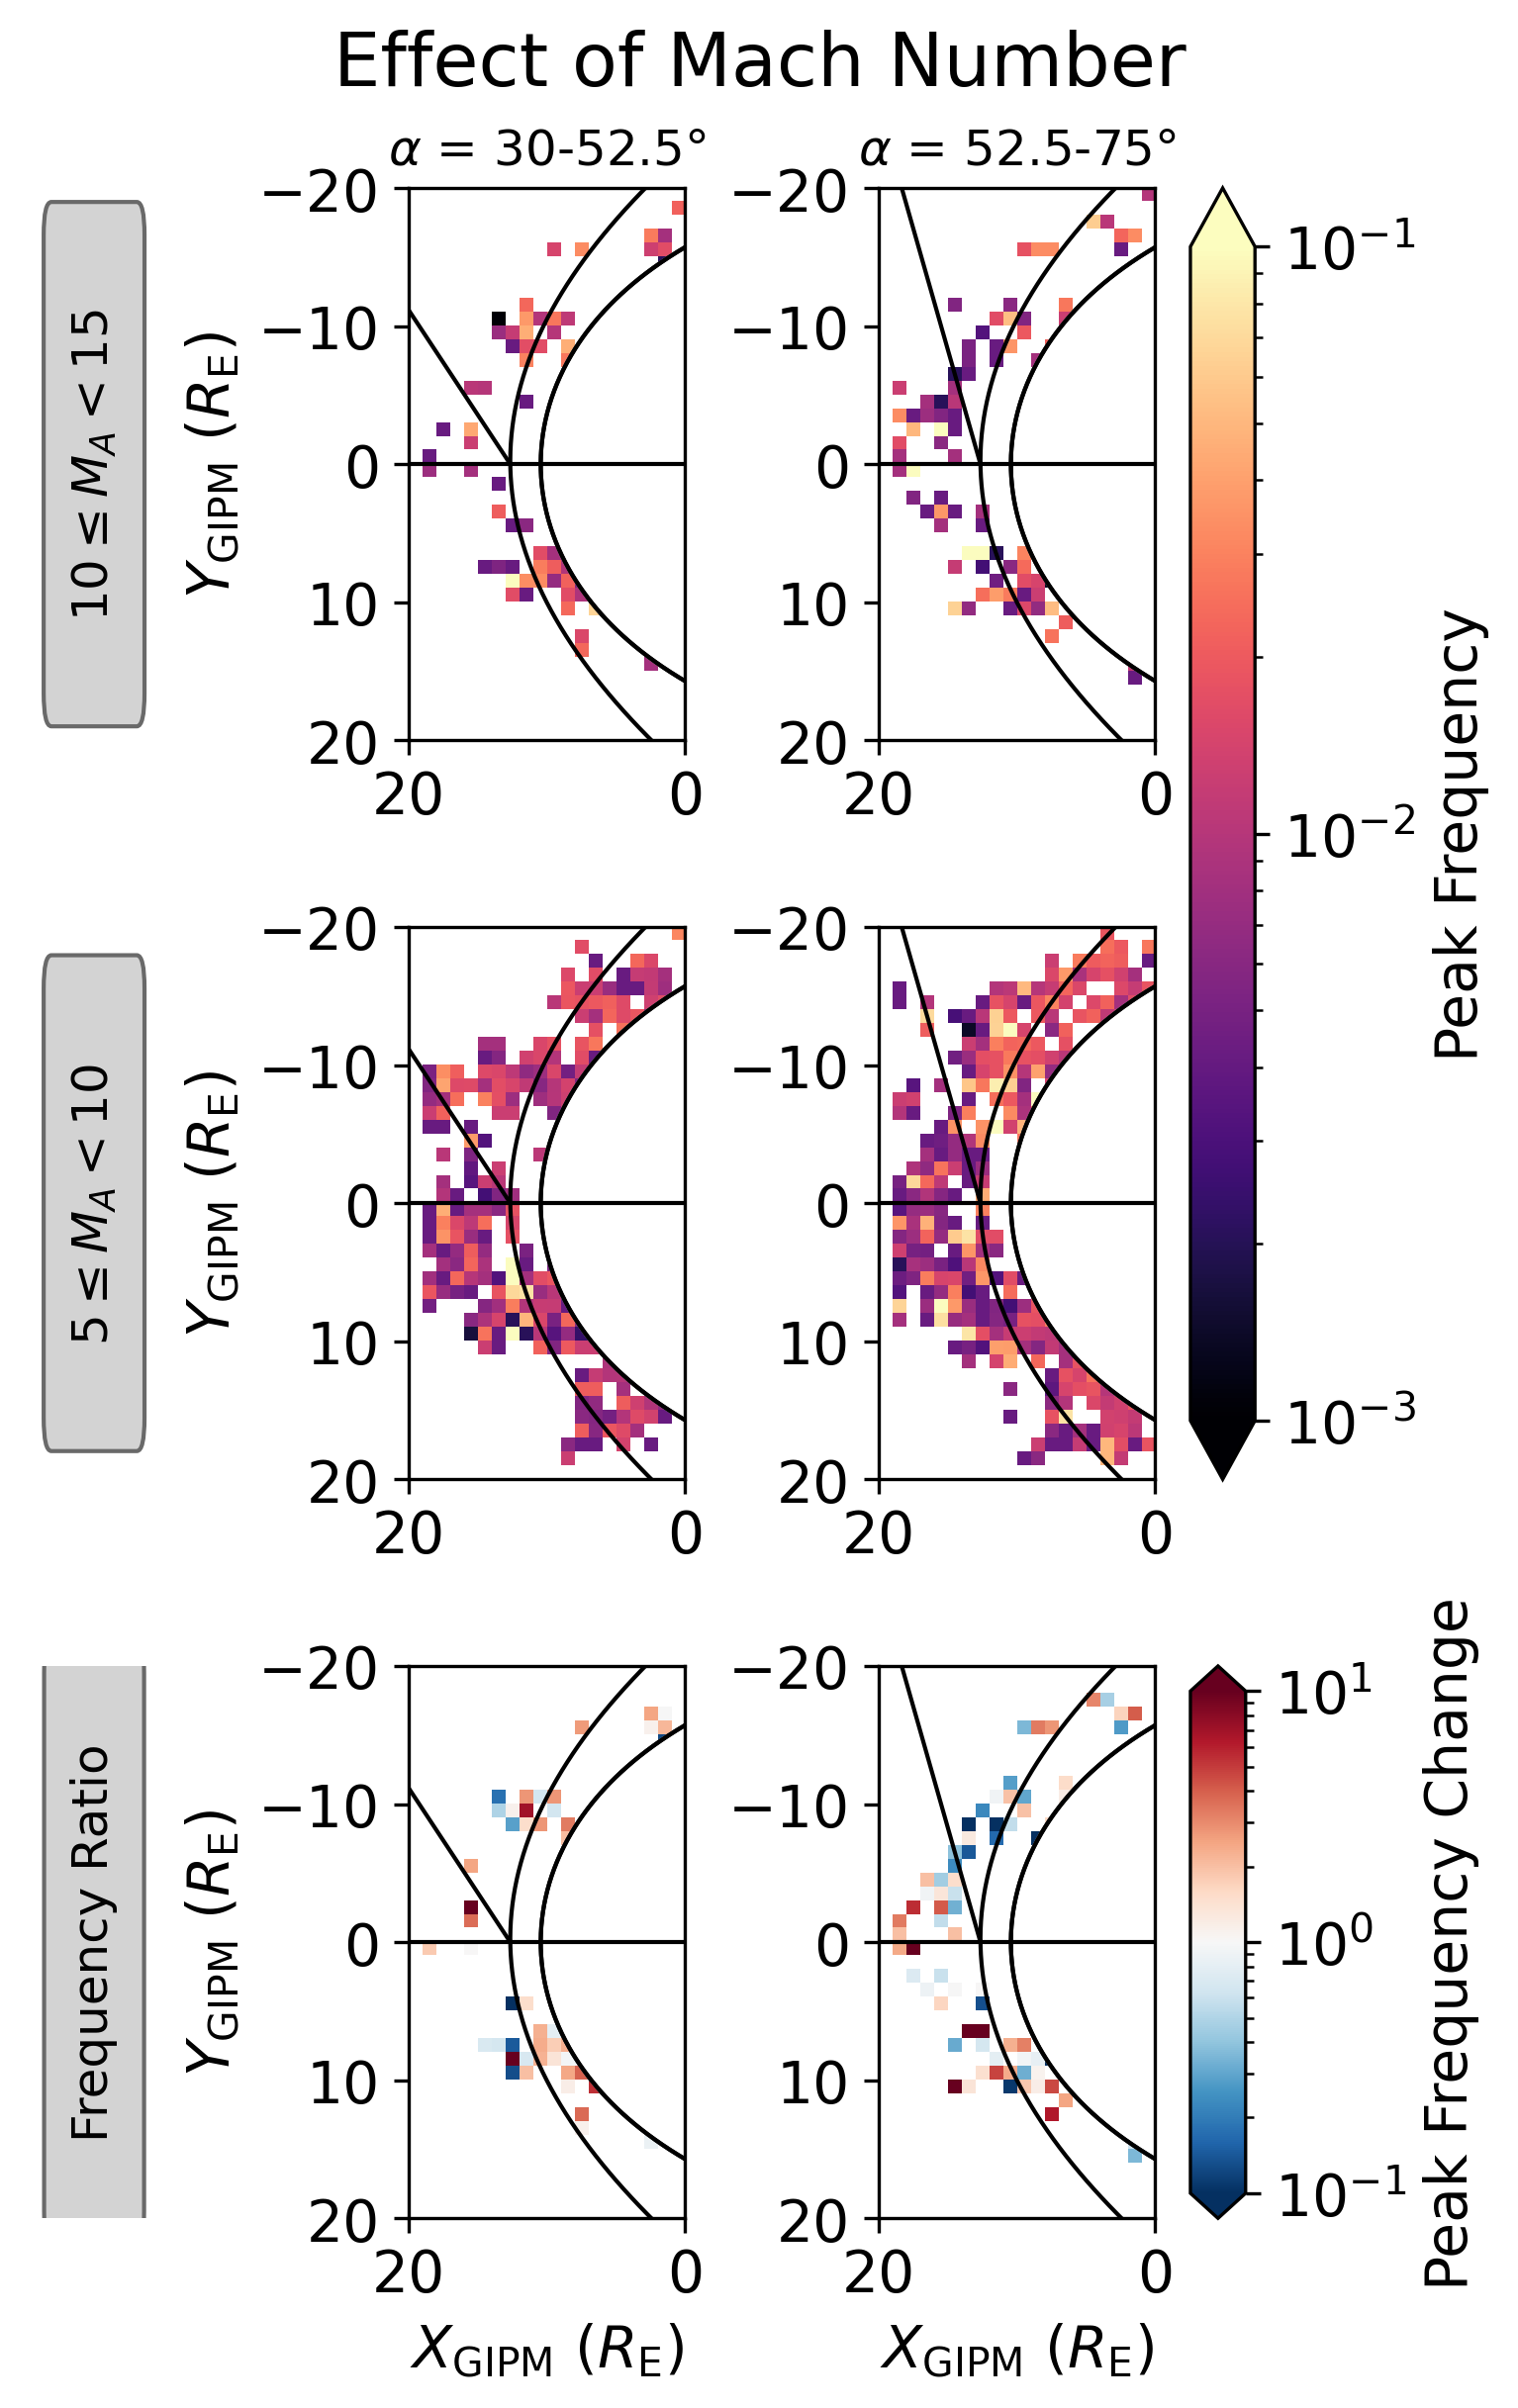

In [24]:
def draw_heatmap(ax, hist, extent, cmap, cmap_norm, angle_line):
    """Draw heatmap + flow line"""
    ax.imshow(hist, interpolation='none', origin='lower',
              extent=extent, cmap=cmap, norm=cmap_norm)
    
    x_s, x_e, y_s, y_e = angle_line
    ax.plot([x_s, x_e], [y_s, angle_line[3]], color='k', linewidth=1)

angle_titles_wide = ["30-52.5°", "52.5-75°"]
# -------------------------------
# CREATE FIGURE + GRID
# -------------------------------

fig = plt.figure(figsize=(5, 8), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3, ncols=3,      # 1 column for patch labels
    width_ratios=[0.35, 1, 1],  # label column thinner
    wspace=0.05, hspace=0.1
)

fig.suptitle("Effect of Mach Number", fontsize=18)
plt.rcParams['axes.labelsize'] = 14

# Row labels (top row → bottom row)
row_labels = [
    r'$10 \leq M_A < 15$',
    r'$5 \leq M_A < 10$',
    r'Frequency Ratio'
]

# -------------------------------
# MAKE AXES FOR THE 3×5 PANELS
# -------------------------------
axs = []
for r in range(3):
    plot_row_axes = []
    gs_row = r      
    for c in range(2):
        ax = fig.add_subplot(gs[gs_row, c + 1])
        plot_row_axes.append(ax)
    axs.append(plot_row_axes)

# -------------------------------
# Patch Labels (Rounded Boxes)
# -------------------------------

for r in range(3):
    ax_patch = fig.add_subplot(gs[r, 0])
    ax_patch.set_axis_off()

    # -- Draw text first so we can query its bounding box --
    txt = ax_patch.text(
        0.5, 0.5,                     # centered in the Axes
        row_labels[r],
        ha="center",
        va="center",
        fontsize=12,
        transform=ax_patch.transAxes,
        rotation='vertical'
    )

    fig.canvas.draw()  # required to obtain correct text bounding box

    # -- Convert text bounding box from display to Axes coordinates --
    renderer = fig.canvas.get_renderer()
    bbox = txt.get_window_extent(renderer=renderer)
    bbox_axes = TransformedBbox(
        bbox, ax_patch.transAxes.inverted()
    )

    # Add some padding around the text
    pad_x = 0.04   # fractional padding in axes coordinates
    pad_y = 0.01

    x0 = bbox_axes.x0 - pad_x
    y0 = bbox_axes.y0 - pad_y
    width = bbox_axes.width + 2 * pad_x
    height = bbox_axes.height + 2 * pad_y

    # -- Rounded box placed behind the text --
    box = FancyBboxPatch(
        (x0, y0),
        width,
        height,
        boxstyle="round,pad=0.2,rounding_size=0.06",
        fc="lightgrey",
        ec="dimgrey",
        linewidth=1,
        mutation_aspect=1,
        transform=ax_patch.transAxes,
        zorder=0.5,
    )
    ax_patch.add_patch(box)

    # Move text above box
    txt.set_zorder(1)


# -------------------------------
# COLORMAP
# -------------------------------

powercmp = 'magma'
power_norm = colors.LogNorm(vmin=0.001, vmax=0.1)
ratio_cmp = 'RdBu_r'
ratio_norm = colors.LogNorm(vmin=0.1, vmax=10)

# -------------------------------
# PLOT ALL PANELS
# -------------------------------

for col in range(2):                         # angle class
    title = angle_titles_wide[col]
    slope = line_slopes[title]
    y_e = -x_e * slope

    for row in range(3):                     # mach no. class
        ax = axs[row][col]

        # Draw contour, magnetopause
        draw_background(ax, Xgipm[:, :, 0], Ygipm[:, :, 0], f[:, :, 0],
                        X_shue, R_shue)

        # Histogram for this cell
        hist = freq_blocks[row][col]

        # angle line parameters: (x_s, x_e, y_s, y_e)
        angle_line = (x_s, x_e, y_s, y_e)

        if row < 2:
            draw_heatmap(ax, hist, extent, powercmp, power_norm, angle_line)

        if row == 2:
            draw_heatmap(ax, hist, extent, ratio_cmp, ratio_norm, angle_line)

        mask_inside_magnetopause(ax, X_shue, R_shue)
        
        # redraw magnetopause boundary so it stays crisp
        ax.plot(X_shue, R_shue, 'k', linewidth=1)
        
        set_limits(ax)
        
        # Labels
        if col == 0:
            ax.set_ylabel("$Y_\\mathrm{GIPM}$ ($R_\\mathrm{E}$)")
        if row == 0:
            ax.set_title(rf'$\alpha$ = {title}', fontsize=12)
        if row == 2:
            ax.set_xlabel("$X_\\mathrm{GIPM}$ ($R_\\mathrm{E}$)")

# -------------------------------
# COLORBARS (TWO SEPARATE ON RIGHT)
# -------------------------------

from matplotlib.cm import ScalarMappable

# --- Scalar mappables (independent of any single subplot image)
sm_power = ScalarMappable(norm=power_norm, cmap=powercmp)
sm_power.set_array([])

sm_ratio = ScalarMappable(norm=ratio_norm, cmap=ratio_cmp)
sm_ratio.set_array([])

# --- Top two rows colourbar (wave power)
top_axes = axs[0] + axs[1]   # flatten row 0 and 1
cbar1 = fig.colorbar(
    sm_power,
    ax=top_axes,
    location='right',
    pad=0.02,
    extend='both'
)
cbar1.set_label('Peak Frequency')

# --- Bottom row colourbar (ratio)
bottom_axes = axs[2]
cbar2 = fig.colorbar(
    sm_ratio,
    ax=bottom_axes,
    location='right',
    aspect=10,
    pad=0.02,
    extend='both'
)
cbar2.set_label('Peak Frequency Change')

cbar1.ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
cbar2.ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())


plt.show()
